In [1]:
# Cell 1
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

# We will tell matplotlib to draw our graphs reasonably large
plt.rcParams['figure.figsize'] = (10, 10)


In [2]:
# Cell 2
# Let's open just the Red band (B04) to look at its metadata
file_path = "data/s2_B04.tif"

with rasterio.open(file_path) as src:
    print("=== SATELLITE IMAGE METADATA ===")
    
    # 1. Spatial Resolution: How much ground does one pixel cover?
    # Sentinel-2 B04 is 10m resolution (1 pixel = 10x10 meters on the ground)
    print(f"Image Size (Pixels): {src.width} wide x {src.height} high")
    
    # 2. Bounding Box: The actual box on Earth this image covers
    print(f"Bounding Box: {src.bounds}")
    
    # 3. CRS (Coordinate Reference System)
    # EPSG:4326 means standard Latitude/Longitude (like Google Maps)
    # EPSG:32643 means a specific flat projection for India
    print(f"CRS: {src.crs}")
    
    # 4. NoData Value: Satellites sometimes have empty black triangles at the edges
    # if the camera was tilted. This tells us what number represents "empty".
    print(f"NoData Value: {src.nodata}")
    
    # Let's actually read the pixels into a numpy matrix!
    # We read band '1' (since this specific file only contains one band, the Red band)
    red_pixels = src.read(1)


=== SATELLITE IMAGE METADATA ===
Image Size (Pixels): 1066 wide x 1120 high
Bounding Box: BoundingBox(left=268410.0, bottom=2102150.0, right=279070.0, top=2113350.0)
CRS: EPSG:32643
NoData Value: 0.0


In [3]:
# Cell 3
def load_band(band_name):
    """A helper function to open a TIFF and convert the pixels to Reflectance (0.0 to 1.0)"""
    with rasterio.open(f"data/s2_{band_name}.tif") as src:
        # Read the pixel matrix as floating point decimals
        pixels = src.read(1).astype(float)
        
        # Sentinel-2 stores Reflectance multiplied by 10,000.
        # So a pixel value of 5000 actually means 0.5 (or 50% reflectance).
        # We divide by 10000 to get the true physical value!
        pixels = pixels / 10000.0
        
        # Clamp values between 0.0 and 1.0 just in case there are bright anomalies (like glint)
        pixels = np.clip(pixels, 0.0, 1.0)
        return pixels

# Load the four bands we downloaded
blue = load_band("B02")
green = load_band("B03")
red = load_band("B04")
nir = load_band("B08") # Near-Infrared (invisible to human eyes)

print("All 4 optical bands successfully loaded into memory as Numpy arrays!")


All 4 optical bands successfully loaded into memory as Numpy arrays!


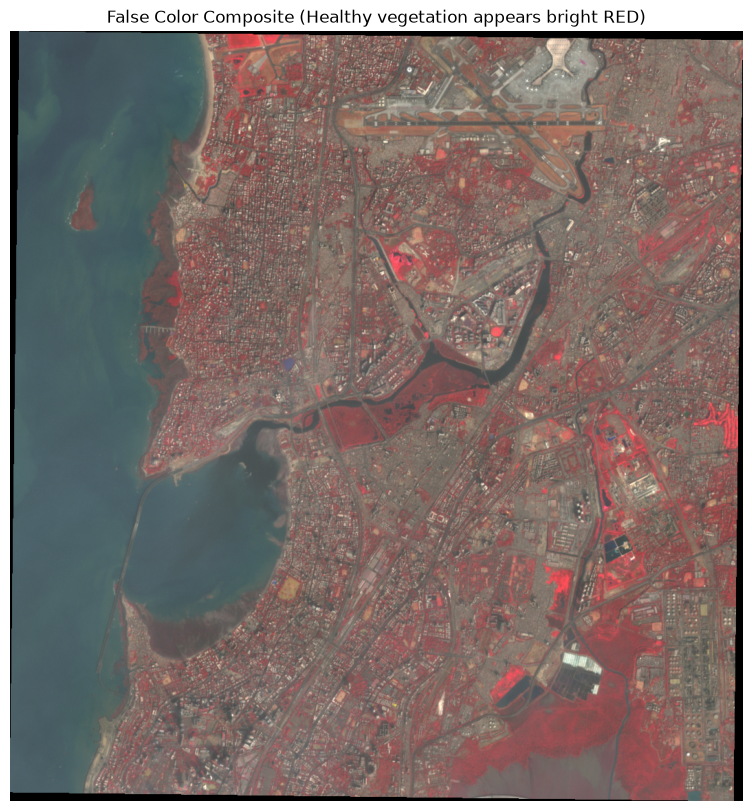

In [4]:
# Cell 5
# Instead of (Red, Green, Blue), we stack (NIR, Red, Green)
false_color_image = np.dstack((nir, red, green))

# Brighten it up a bit
false_color_image = np.clip(false_color_image * 2.0, 0.0, 1.0)

# Create the plot
plt.figure(figsize=(10, 10))
plt.imshow(false_color_image)
plt.title("False Color Composite (Healthy vegetation appears bright RED)")
plt.axis("off")
plt.show()
